# Coding Exercise 3: U-Net score estimation and MNIST sampling (Solutions)

In Exercise 2 we estimated scores for low-dimensional distributions and then used the learned score in a reverse OU sampler. In this exercise we repeat the same idea for images.

You will

1. load MNIST images and normalize them to the range $[-1,1]$,
2. train a small time-conditioned U-Net to estimate the score $\nabla \log q_t(x)$ of the noised MNIST distribution,
3. sample images with the reverse-time OU SDE,
4. compare the Lecture 9 DDPM and DDIM discretizations.

We use the forward OU process
$$
dX_t=-X_t\,dt+\sqrt 2\,dB_t,\qquad X_0\sim q,
$$
so that
$$
X_t=e^{-t}X_0+\sqrt{1-e^{-2t}}\,\varepsilon,\qquad \varepsilon\sim N(0,I).
$$


In [1]:
import math
from itertools import cycle
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm import tqdm


from util import SDE, Simulator, EulerMaruyama
import knn_helper as knn


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

np.random.seed(12345)
torch.manual_seed(12345)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(12345)
    torch.backends.cudnn.benchmark = True


Using device: cpu


## Section 1: MNIST data

Download and load the MNIST dataset.

We use `torchvision.datasets.MNIST`, which downloads MNIST for us and returns each image with its label. The only transform we add converts each image to a PyTorch tensor and rescales pixel values from `[0, 1]` to `[-1, 1]`, which is the range used by the diffusion model.


In [2]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),                      # PIL image -> tensor with values in [0, 1]
    transforms.Lambda(lambda x: 2.0 * x - 1.0),  # [0, 1] -> [-1, 1]
])

def to_display_range(images: torch.Tensor) -> torch.Tensor:
    '''Map image tensors from [-1, 1] to [0, 1] for plotting.'''
    return ((images.detach().cpu().clamp(-1.0, 1.0) + 1.0) / 2.0)


def make_image_grid(images: torch.Tensor, nrow: int = 8, padding: int = 2, pad_value: float = 1.0) -> torch.Tensor:
    images = to_display_range(images)
    if images.ndim != 4:
        raise ValueError(f"Expected images of shape (B, C, H, W), got {tuple(images.shape)}.")
    num_images, channels, height, width = images.shape
    ncol = min(nrow, num_images)
    nrows = int(math.ceil(num_images / ncol))
    grid_height = nrows * height + padding * (nrows - 1)
    grid_width = ncol * width + padding * (ncol - 1)
    grid = images.new_full((channels, grid_height, grid_width), pad_value)
    for idx, image in enumerate(images):
        row = idx // ncol
        col = idx % ncol
        y0 = row * (height + padding)
        x0 = col * (width + padding)
        grid[:, y0:y0 + height, x0:x0 + width] = image
    return grid


def show_image_grid(images: torch.Tensor, nrow: int = 8, title: str | None = None) -> None:
    grid = make_image_grid(images, nrow=nrow)
    plt.figure(figsize=(1.4 * nrow, 1.4 * math.ceil(images.shape[0] / nrow)))
    if grid.shape[0] == 1:
        plt.imshow(grid.squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
    else:
        plt.imshow(grid.permute(1, 2, 0))
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()


Batch shape: (64, 1, 28, 28) labels shape: (64,)


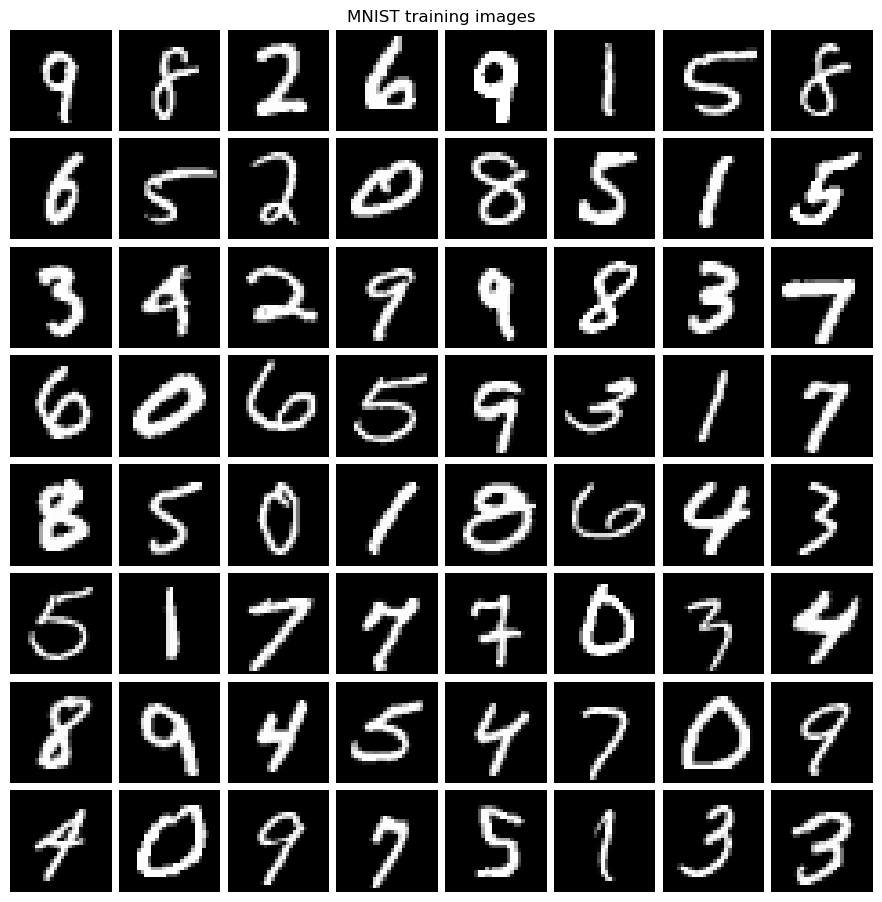

In [3]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=mnist_transform,
)

# Can use a subset on CPU so that the exercise remains lightweight
train_dataset_for_loader = train_dataset

batch_size = 64
train_loader = DataLoader(
    train_dataset_for_loader,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

x_batch, y_batch = next(iter(train_loader))
print("Batch shape:", tuple(x_batch.shape), "labels shape:", tuple(y_batch.shape))
show_image_grid(x_batch[:64], nrow=8, title="MNIST training images")


## Section 2: Forward OU simulation and time parameterization

For the forward OU process,
$$
X_t=e^{-t}X_0+\sigma_t\varepsilon,\qquad \sigma_t=\sqrt{1-e^{-2t}}.
$$
Given a clean image $X_0$ and the sampled noise $\varepsilon$, the conditional score is
$$
\nabla_x\log q_{t|0}(x|X_0)=-\frac{x-e^{-t}X_0}{\sigma_t^2}=-\frac{\varepsilon}{\sigma_t}.
$$
Denoising score matching regresses the neural network onto this conditional score.

### Question 3.1 - OU noising and score target

Complete `alpha_t`, `sigma_t`, and the last few lines of `sample_forward_ou`. The shape handling is already provided; focus on the OU formulas for $X_t$ and the conditional score target $-\varepsilon/\sigma_t$.


In [4]:
def as_batch_time(t: torch.Tensor | float, batch_size: int, device: torch.device, dtype: torch.dtype = torch.float32) -> torch.Tensor:
    '''Convert a time value into a tensor with one entry per image in the batch.'''
    if not torch.is_tensor(t):
        t = torch.tensor(t, device=device, dtype=dtype)
    else:
        t = t.to(device=device, dtype=dtype)
    # If one time is given, use the same time for every image in the batch.
    if t.ndim == 0:
        t = t.expand(batch_size)
    # Otherwise, we expect one time value per image.
    if t.shape[0] != batch_size:
        raise ValueError(f"Expected time batch of length {batch_size}, got {tuple(t.shape)}.")
    return t


def expand_time(t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    '''Reshape a batch of times so it can multiply an image batch.'''
    # Change shape from (B,) to (B, 1, 1, 1), so it broadcasts over C, H, and W.
    return t.view(t.shape[0], *([1] * (x.ndim - 1)))


def alpha_t(t: torch.Tensor) -> torch.Tensor:
    '''Return the OU coefficient multiplying the clean image X_0.'''
    # OU mean coefficient: the clean image contribution decays as time grows.
    return torch.exp(-t)


def sigma_t(t: torch.Tensor) -> torch.Tensor:
    '''Return the OU standard deviation multiplying the Gaussian noise.'''
    # OU noise standard deviation. The clamp prevents tiny negative round-off errors.
    return torch.sqrt(torch.clamp(1.0 - torch.exp(-2.0 * t), min=1e-12))


def sample_forward_ou(x0: torch.Tensor, t: torch.Tensor | float) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    '''
    Create a noisy image X_t from a clean image X_0.

    Returns the noisy image, the exact conditional score target, and the noise eps.
    '''
    # Make sure t has shape (batch_size,) and lives next to x0.
    t = as_batch_time(t, x0.shape[0], x0.device, x0.dtype)

    # Draw one standard-normal noise image for each clean image.
    eps = torch.randn_like(x0)

    # Expand alpha and sigma so they multiply every pixel of each image.
    alpha = expand_time(alpha_t(t), x0)
    sigma = expand_time(sigma_t(t), x0)

    # Forward OU sample: keep part of x0 and add Gaussian noise.
    xt = alpha * x0 + sigma * eps

    # Score of q(x_t | x_0), used as the denoising score matching target.
    conditional_score = -eps / sigma
    return xt, conditional_score, eps


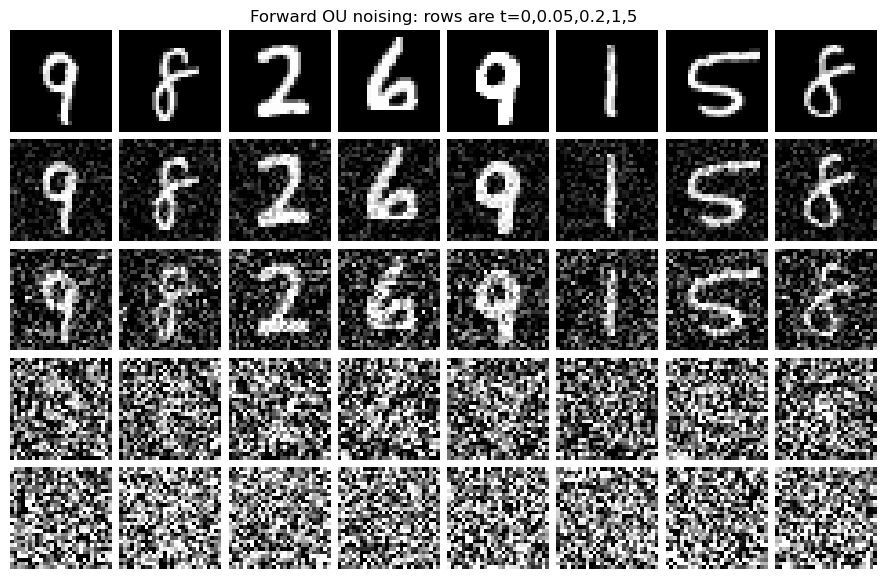

In [5]:
# Visualize noising at a few times.
x0_vis = x_batch[:8].to(device)
times_to_show = torch.tensor([0.0, 0.05, 0.2, 1.0, 5.0], device=device)

noised_rows = []
with torch.no_grad():
    for t_value in times_to_show:
        xt, _, _ = sample_forward_ou(x0_vis, t_value)
        noised_rows.append(xt.cpu())
noised_grid = torch.cat(noised_rows, dim=0)
show_image_grid(noised_grid, nrow=8, title="Forward OU noising: rows are t=0,0.05,0.2,1,5")

## Section 3: A time-conditioned U-Net score model

The score network takes a noisy image $x_t$ and the forward noising time $t$ as input and returns an image-shaped estimate of $\nabla \log q_t(x_t)$.

The score depends on the noise level $t$, so the U-Net must be conditioned on time. Instead of passing the scalar $t$ directly, `SinusoidalTimeEmbedding` maps it to
$$
\gamma(t)=\big(\sin(\omega_1t),\cos(\omega_1t),\ldots,\sin(\omega_mt),\cos(\omega_mt)\big),
$$
where the frequencies $\omega_i$ span multiple scales. Low frequencies represent broad changes over time, while high frequencies help distinguish nearby times.

A small MLP then turns $\gamma(t)$ into a learned time vector that is injected into each convolution block, allowing the U-Net to use different denoising rules for different $t$.

### Question 3.2 - U-Net forward pass

Complete the two skip connections in `TinyUNetScore.forward`. The encoder and upsampling calls are provided; focus on concatenating same-resolution features along the channel dimension.


In [6]:
def choose_num_groups(channels: int) -> int:
    """Return a GroupNorm group count that divides the channel count."""
    for groups in (8, 4, 2):
        if channels % groups == 0:
            return groups
    return 1


class SinusoidalTimeEmbedding(nn.Module):
    """Map scalar diffusion times to sinusoidal features at many frequencies."""

    def __init__(self, dim: int):
        """Store the requested embedding dimension."""
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """Encode a batch of times as sine and cosine frequency features."""
        if t.ndim == 0:
            t = t[None]
        half_dim = self.dim // 2
        exponent = torch.arange(half_dim, device=t.device, dtype=t.dtype)
        frequencies = torch.exp(-math.log(10_000.0) * exponent / max(half_dim - 1, 1))
        angles = t[:, None] * frequencies[None, :]
        embedding = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
        if self.dim % 2 == 1:
            embedding = torch.nn.functional.pad(embedding, (0, 1))
        return embedding


class TimeConvBlock(nn.Module):
    """Two 3x3 convolutions with GroupNorm and additive time conditioning."""

    def __init__(self, in_channels: int, out_channels: int, time_dim: int):
        """Build a resolution-preserving convolution block conditioned on time."""
        super().__init__()
        # The first 3x3 convolution changes the channel count but keeps H x W fixed.
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        # Normalization layer. GroupNorm is stable for small batches because it avoids batch statistics.
        self.norm1 = nn.GroupNorm(choose_num_groups(out_channels), out_channels)
        # Project the time embedding to a per-channel bias that broadcasts over H x W.
        self.time_proj = nn.Linear(time_dim, out_channels)
        # The second 3x3 convolution refines features at the same resolution.
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(choose_num_groups(out_channels), out_channels)
        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        """Apply the convolution block and inject the time embedding after norm1."""
        h = self.conv1(x)
        h = self.norm1(h)
        h = h + self.time_proj(time_emb)[:, :, None, None]
        h = self.act(h)
        h = self.conv2(h)
        h = self.norm2(h)
        return self.act(h)


class TinyUNetScore(nn.Module):
    """A small time-conditioned U-Net that predicts image-shaped OU scores."""

    def __init__(self, base_channels: int = 32, time_dim: int = 128):
        """Construct the time MLP, encoder, bottleneck, decoder, and output head."""
        super().__init__()
        # Convert scalar t into the vector injected into every convolution block.
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        c = base_channels
        # Encoder level 1: lift the 1-channel MNIST image to c feature maps at 28 x 28.
        self.in_block = TimeConvBlock(1, c, time_dim)
        # Downsampling halves spatial size while doubling channels: c @ 28 -> 2c @ 14.
        self.downsample1 = nn.Conv2d(c, 2 * c, kernel_size=4, stride=2, padding=1)
        self.down_block1 = TimeConvBlock(2 * c, 2 * c, time_dim)
        # A second downsampling gives a compact 7 x 7 representation with 4c channels.
        self.downsample2 = nn.Conv2d(2 * c, 4 * c, kernel_size=4, stride=2, padding=1)
        self.mid_block = TimeConvBlock(4 * c, 4 * c, time_dim)

        # Decoder level 2: transpose convolution restores 7 -> 14 and reduces to 2c channels.
        self.upsample1 = nn.ConvTranspose2d(4 * c, 2 * c, kernel_size=4, stride=2, padding=1)
        # Concatenating with the matching encoder skip gives 2c + 2c = 4c input channels.
        self.up_block1 = TimeConvBlock(4 * c, 2 * c, time_dim)
        # Decoder level 1: restore 14 -> 28 and reduce to c channels.
        self.upsample2 = nn.ConvTranspose2d(2 * c, c, kernel_size=4, stride=2, padding=1)
        # Concatenating with the first skip gives c + c = 2c input channels.
        self.up_block2 = TimeConvBlock(2 * c, c, time_dim)
        # Final 3x3 projection returns one score value per image pixel.
        self.out = nn.Conv2d(c, 1, kernel_size=3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """Predict the score for noisy images x at forward noising times t."""
        t = as_batch_time(t, x.shape[0], x.device, x.dtype)
        time_emb = self.time_mlp(t)

        # Encoder path: save h1 and h2 for same-resolution skip connections.
        h1 = self.in_block(x, time_emb)
        h2 = self.down_block1(self.downsample1(h1), time_emb)
        h3 = self.mid_block(self.downsample2(h2), time_emb)

        # Decoder path: upsample, concatenate the matching skip, then refine.
        u2 = self.upsample1(h3)
        u2 = torch.cat([u2, h2], dim=1)
        u2 = self.up_block1(u2, time_emb)

        u1 = self.upsample2(u2)
        u1 = torch.cat([u1, h1], dim=1)
        u1 = self.up_block2(u1, time_emb)
        return self.out(u1)

In [7]:
# Shape sanity check.
score_model_debug = TinyUNetScore(base_channels=16).to(device)
with torch.no_grad():
    debug_t = torch.full((4,), 0.5, device=device)
    debug_out = score_model_debug(x_batch[:4].to(device), debug_t)
print("Debug output shape:", tuple(debug_out.shape))
del score_model_debug, debug_out
if device.type == "cuda":
    torch.cuda.empty_cache()


Debug output shape: (4, 1, 28, 28)


### Question 3.3 - Denoising score matching loss

Implement the time-dependent denoising score matching objective
$$
\mathbb E\left[\lambda(t)\,\left\|s_\theta(X_t,t)+\frac{\varepsilon}{\sigma_t}\right\|^2\right].
$$
We use the common choice $\lambda(t)=\sigma_t^2$ and average over pixels. The noising and prediction calls are provided; complete the per-image mean squared error and weighting.


In [8]:
def denoising_score_matching_loss(
    score_model: nn.Module,
    x0: torch.Tensor,
    t: torch.Tensor,
    weighting: str = "sigma2",
) -> torch.Tensor:
    """Compute the denoising score matching loss for OU-perturbed images."""
    xt, target_score, _ = sample_forward_ou(x0, t)
    pred_score = score_model(xt, t)

    per_example_loss = ((pred_score - target_score) ** 2).flatten(1).mean(dim=1)
    if weighting == "sigma2":
        weights = sigma_t(t) ** 2
    elif weighting == "none":
        weights = torch.ones_like(t)
    else:
        raise ValueError(f"Unknown weighting: {weighting}")
    return (weights * per_example_loss).mean()


def train_score_model(
    score_model: nn.Module,
    loader: DataLoader,
    num_steps: int,
    T: float,
    t_min: float,
    lr: float = 2e-4,
    weighting: str = "sigma2",
) -> list[float]:
    """Train the score model by sampling fresh images and noising times each step."""
    score_model.train()
    optimizer = torch.optim.AdamW(score_model.parameters(), lr=lr, weight_decay=1e-4)
    losses: list[float] = []
    data_iter = cycle(loader)
    pbar = tqdm(range(num_steps))
    for step in pbar:
        x0, _ = next(data_iter)
        x0 = x0.to(device)
        t = t_min + (T - t_min) * torch.rand(x0.shape[0], device=device)

        loss = denoising_score_matching_loss(score_model, x0, t, weighting=weighting)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(score_model.parameters(), max_norm=1.0)
        optimizer.step()

        losses.append(float(loss.detach().cpu()))
        if step % 50 == 0:
            pbar.set_description(f"loss={losses[-1]:.4f}")
    return losses


In [9]:
# Training parameters.
T = 5.0
t_min = 0.02
# Increase num_train_steps substantially for nicer samples.
num_train_steps = num_train_steps = 30_000 if device.type == "cuda" else 5_000

checkpoint_dir = Path("checkpoints")
checkpoint_dir.mkdir(exist_ok=True)
checkpoint_path = checkpoint_dir / f"ex3_mnist_ou_score_unet_{num_train_steps:06d}.pt"

score_model = TinyUNetScore(base_channels=32, time_dim=64).to(device)
loss_history: list[float] = []

if checkpoint_path.exists():
    print(f"Loading checkpoint from {checkpoint_path}")
    state_dict = torch.load(checkpoint_path, map_location=device)
    score_model.load_state_dict(state_dict)
else:
    print(f"Training for {num_train_steps} steps. For better samples, increase num_train_steps.")
    loss_history = train_score_model(
        score_model,
        train_loader,
        num_steps=num_train_steps,
        T=T,
        t_min=t_min,
        lr=2e-4,
        weighting="sigma2",
    )
    torch.save(score_model.state_dict(), checkpoint_path)
    print(f"Saved checkpoint to {checkpoint_path}")


Training for 5000 steps. For better samples, increase num_train_steps.


loss=0.0085: 100%|██████████| 5000/5000 [22:04<00:00,  3.78it/s]

Saved checkpoint to checkpoints/ex3_mnist_ou_score_unet_005000.pt


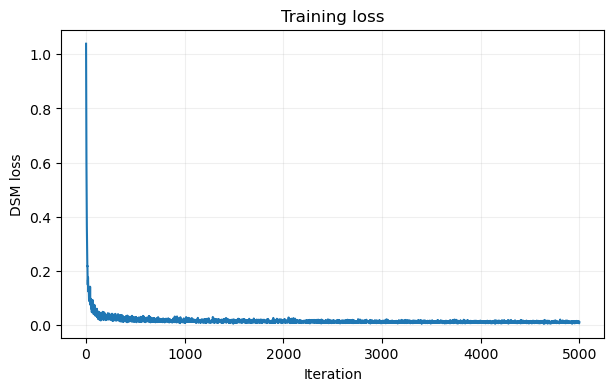

In [10]:
if loss_history:
    plt.figure(figsize=(7, 4))
    plt.plot(loss_history)
    plt.title("Training loss")
    plt.xlabel("Iteration")
    plt.ylabel("DSM loss")
    plt.grid(alpha=0.2)
    plt.show()
else:
    print("No new loss curve to plot because a checkpoint was loaded.")


## Section 4: Reverse-time samplers

Lecture 5's time-reversal formula gives the reverse OU SDE
$$
dY_t=\left[Y_t+2\nabla\log q_{T-t}(Y_t)\right]dt+\sqrt 2\,d\widetilde B_t,
\qquad Y_0\sim q_T.
$$
We approximate the unknown score by the U-Net.

On a reverse-time grid $0=t_0<t_1<\dots<t_K=T-\delta$, write $h_k=t_{k+1}-t_k$, $\tau_k=T-t_k$, and
$$
b_k^2=1-e^{-2\tau_k}.
$$

Lecture 9 gives the DDPM update
$$
\widehat Y_{k+1}=e^{h_k}\left[\widehat Y_k+(1-e^{-2h_k})s_{\tau_k}(\widehat Y_k)\right]
+\sqrt{\widetilde\beta_k}\,\xi_k,
\qquad
\widetilde\beta_k=(1-e^{-2h_k})\frac{b_{k+1}^2}{b_k^2},
$$
and the stochastic DDIM family
$$
\widehat Y_{k+1}=e^{h_k}\widehat Y_k+
\left(e^{h_k}b_k^2-b_k\sqrt{b_{k+1}^2-\eta^2\widetilde\beta_k}\right)s_{\tau_k}(\widehat Y_k)
+\eta\sqrt{\widetilde\beta_k}\,\xi_k.
$$
The case $\eta=1$ recovers DDPM, while $\eta=0$ gives deterministic DDIM.

### Question 3.4 - Implement the samplers

Complete the reverse SDE drift and the mean formulas in the DDPM/DDIM steps. The helper `reverse_step_quantities` computes $\tau_k$, $b_k$, $b_{k+1}$, and $\widetilde\beta_k$ so you can focus on the update formulas.


In [11]:
def make_reverse_time_grid(
    T: float,
    delta: float,
    num_steps: int,
    kind: str = "mixed",
    device: torch.device | None = None,
) -> torch.Tensor:
    '''Return an increasing reverse-time grid from 0 to T - delta.'''
    if not (0.0 < delta < T):
        raise ValueError("Need 0 < delta < T.")
    if num_steps < 1:
        raise ValueError("num_steps must be positive.")

    if kind == "linear":
        return torch.linspace(0.0, T - delta, num_steps + 1, device=device)

    if kind == "geometric":
        taus = torch.exp(torch.linspace(math.log(T), math.log(delta), num_steps + 1, device=device))
        return T - taus

    if kind == "mixed":
        if T <= 1.0 or delta >= 1.0 or num_steps < 4:
            return make_reverse_time_grid(T, delta, num_steps, kind="linear", device=device)
        n_geometric = max(2, num_steps // 2)
        n_linear = num_steps - n_geometric
        linear_part = torch.linspace(0.0, T - 1.0, n_linear + 1, device=device)
        taus_geo = torch.exp(torch.linspace(0.0, math.log(delta), n_geometric + 1, device=device))
        geometric_part = T - taus_geo
        return torch.cat([linear_part, geometric_part[1:]])

    raise ValueError(f"Unknown grid kind: {kind}")


@torch.no_grad()
def model_score(score_model: nn.Module, x: torch.Tensor, t_forward: torch.Tensor | float, clip_score: float | None = 80.0) -> torch.Tensor:
    t_batch = as_batch_time(t_forward, x.shape[0], x.device, x.dtype)
    score = score_model(x, t_batch)
    if clip_score is not None:
        score = score.clamp(-clip_score, clip_score)
    return score


def reverse_step_quantities(T: float, t: torch.Tensor, dt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    '''Return the forward time and noise coefficients for one reverse step.'''
    tau_k = T - t
    tau_next = T - (t + dt)
    b_k = sigma_t(tau_k)
    b_next = sigma_t(tau_next)
    beta_tilde = (1.0 - torch.exp(-2.0 * dt)) * (b_next ** 2) / (b_k ** 2)
    return tau_k, b_k, b_next, beta_tilde


def add_reverse_noise(mean: torch.Tensor, beta_tilde: torch.Tensor, eta: float = 1.0) -> torch.Tensor:
    '''Add the stochastic part of a reverse DDPM/DDIM step.'''
    if eta == 0.0:
        return mean
    return mean + eta * torch.sqrt(beta_tilde) * torch.randn_like(mean)


class ReverseOUSDE(SDE):
    def __init__(self, score_model: nn.Module, T: float, clip_score: float | None = 80.0):
        self.score_model = score_model
        self.T = float(T)
        self.clip_score = clip_score

    def drift(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        tau = self.T - t
        score = model_score(self.score_model, x, tau, clip_score=self.clip_score)
        return x + 2.0 * score

    def diffusion(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return math.sqrt(2.0) * torch.ones_like(x)


class DDPMSampler(Simulator):
    def __init__(self, score_model: nn.Module, T: float, clip_score: float | None = 80.0):
        self.score_model = score_model
        self.T = float(T)
        self.clip_score = clip_score

    def step(self, x: torch.Tensor, t: torch.Tensor, dt: torch.Tensor) -> torch.Tensor:
        tau_k, _, _, beta_tilde = reverse_step_quantities(self.T, t, dt)
        score = model_score(self.score_model, x, tau_k, clip_score=self.clip_score)
        mean = torch.exp(dt) * (x + (1.0 - torch.exp(-2.0 * dt)) * score)
        return add_reverse_noise(mean, beta_tilde)


class DDIMSampler(Simulator):
    def __init__(self, score_model: nn.Module, T: float, eta: float = 0.0, clip_score: float | None = 80.0):
        if not (0.0 <= eta <= 1.0):
            raise ValueError("eta must be in [0, 1].")
        self.score_model = score_model
        self.T = float(T)
        self.eta = float(eta)
        self.clip_score = clip_score

    def step(self, x: torch.Tensor, t: torch.Tensor, dt: torch.Tensor) -> torch.Tensor:
        tau_k, b_k, b_next, beta_tilde = reverse_step_quantities(self.T, t, dt)
        score = model_score(self.score_model, x, tau_k, clip_score=self.clip_score)

        radicand = torch.clamp(b_next ** 2 - (self.eta ** 2) * beta_tilde, min=0.0)
        score_coeff = torch.exp(dt) * (b_k ** 2) - b_k * torch.sqrt(radicand)
        mean = torch.exp(dt) * x + score_coeff * score
        return add_reverse_noise(mean, beta_tilde, eta=self.eta)


### Sampling helper

The samplers stop at $q_\delta$. For visualization we also use the score model to form the Tweedie-style denoised estimate
$$
\widehat x_0=e^\delta\left(x_\delta+\sigma_\delta^2 s_\delta(x_\delta)\right).
$$


In [12]:
@torch.no_grad()
def denoise_to_x0(score_model: nn.Module, x_delta: torch.Tensor, delta: float) -> torch.Tensor:
    delta_tensor = torch.tensor(delta, device=x_delta.device, dtype=x_delta.dtype)
    score = model_score(score_model, x_delta, delta_tensor, clip_score=80.0)
    return torch.exp(delta_tensor) * (x_delta + (sigma_t(delta_tensor) ** 2) * score)


@torch.no_grad()
def sample_images(
    sampler: Simulator,
    grid: torch.Tensor,
    num_samples: int = 64,
    denoise: bool = True,
) -> torch.Tensor:
    score_model.eval()
    xT = torch.randn(num_samples, 1, 28, 28, device=device)
    x_delta = sampler.simulate(xT, grid)
    if denoise:
        delta_value = float(T - grid[-1].detach().cpu())
        return denoise_to_x0(score_model, x_delta, delta=delta_value)
    return x_delta


Grid length: 1001 final forward time delta: 0.019999980926513672


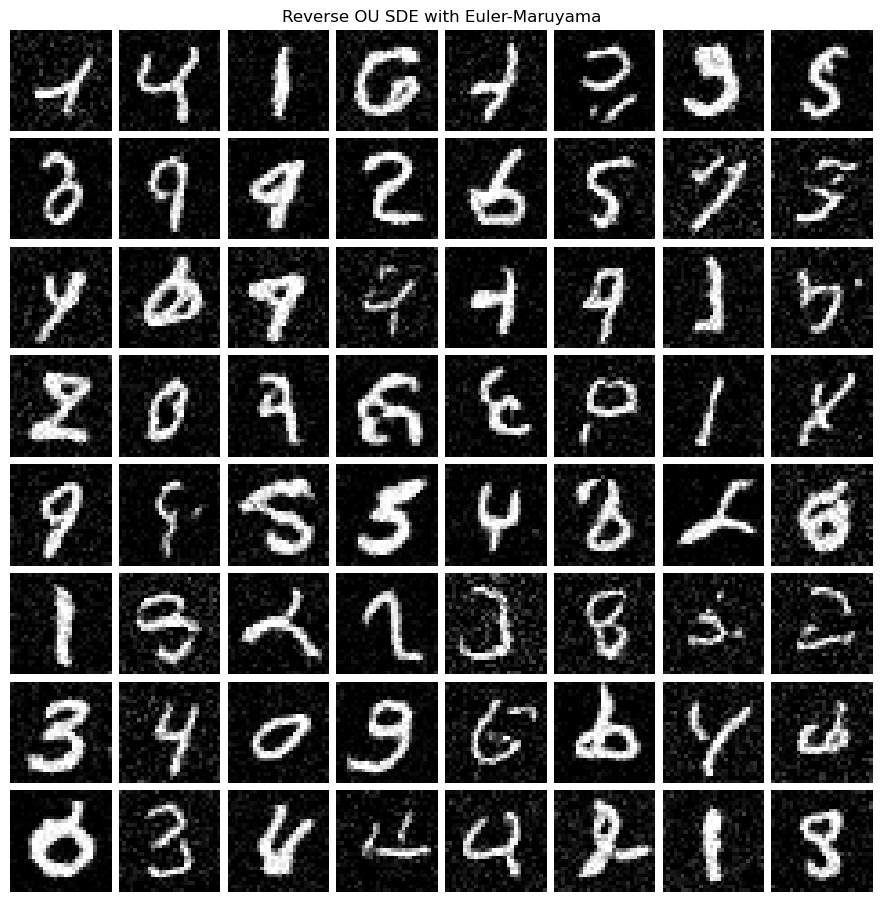

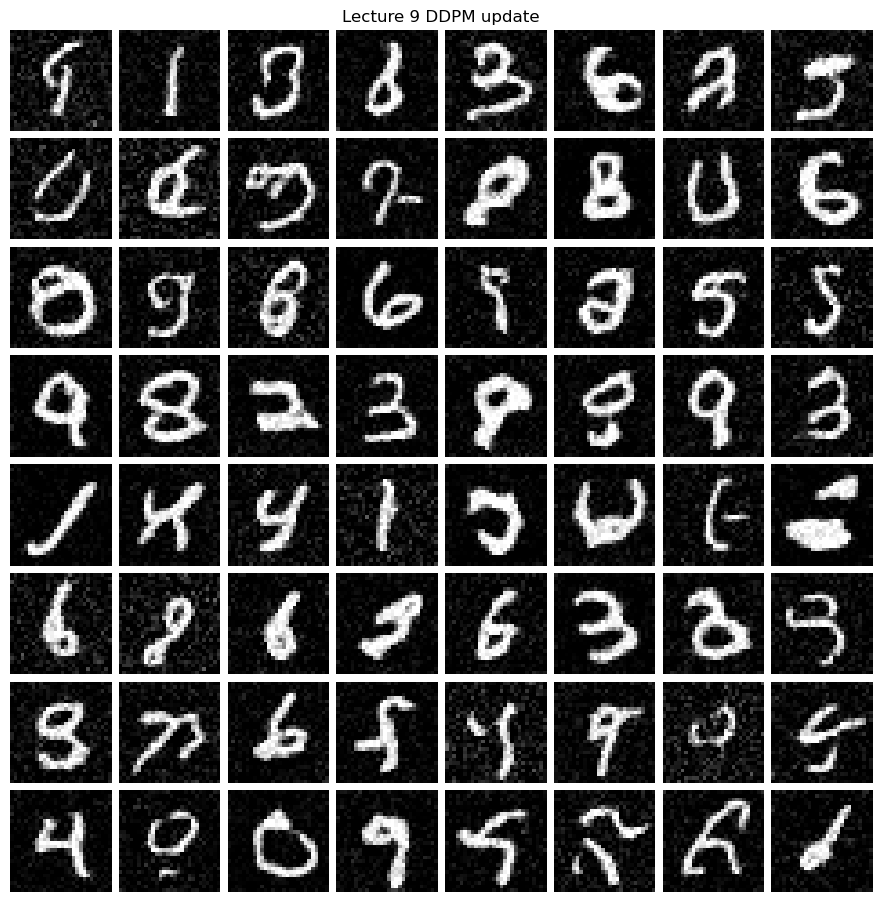

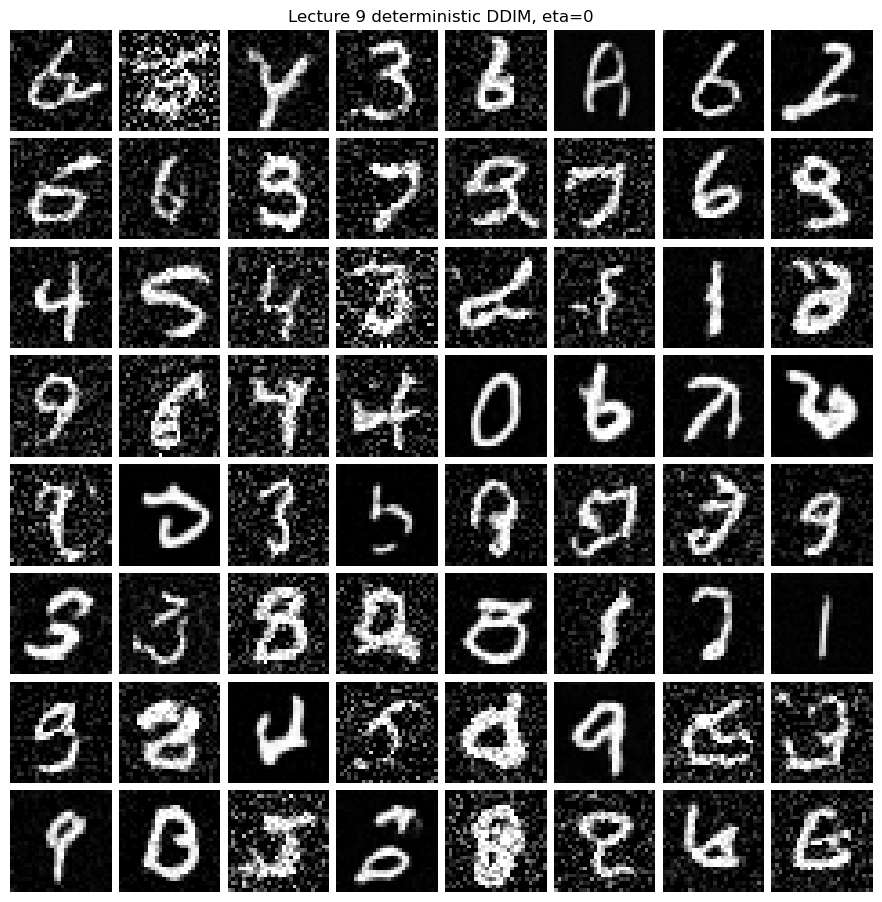

In [13]:
score_model.eval()

delta = 0.02
num_sampling_steps = 1000
reverse_grid = make_reverse_time_grid(T=T, delta=delta, num_steps=num_sampling_steps, kind="mixed", device=device)

print("Grid length:", len(reverse_grid), "final forward time delta:", float(T - reverse_grid[-1]))

# # Euler-Maruyama discretization of the reverse SDE from Lecture 5.
em_sampler = EulerMaruyama(ReverseOUSDE(score_model, T=T))
em_samples = sample_images(em_sampler, reverse_grid, num_samples=64, denoise=True)
show_image_grid(em_samples, nrow=8, title="Reverse OU SDE with Euler-Maruyama")

# Lecture 9 DDPM update.
ddpm_sampler = DDPMSampler(score_model, T=T)
ddpm_samples = sample_images(ddpm_sampler, reverse_grid, num_samples=64, denoise=True)
show_image_grid(ddpm_samples, nrow=8, title="Lecture 9 DDPM update")

# Lecture 9 deterministic DDIM update.
ddim_sampler = DDIMSampler(score_model, T=T, eta=0.0)
ddim_samples = sample_images(ddim_sampler, reverse_grid, num_samples=64, denoise=True)
show_image_grid(ddim_samples, nrow=8, title="Lecture 9 deterministic DDIM, eta=0")


## Section 5: Nearest-neighbor sanity check against the training set

A common concern with image generation is that a model might simply copy training images. As a quick check, we take 16 generated DDPM images and, for each one, search the full MNIST training set for the closest image in normalized pixel RMSE.

This is a sanity check rather than a formal memorization/privacy proof. If a generated image were an exact training-set image, its nearest-neighbor MSE would be essentially zero. We also include an exact 8-bit pixel check after quantizing the generated image back to MNIST's original pixel grid.

In the comparison grid, each group is shown as

`generated sample | nearest training image | absolute difference`.

The reusable nearest-neighbor search, printing, and visualization code lives in `knn_helper.py`, so the notebook cell below only needs to call one helper and then interpret the output.

### Question 3.5 - Nearest-neighbor sanity check

Call `knn.run_nearest_neighbor_check` below. Are any generated samples exact 8-bit matches to MNIST training images? For a few generated samples, compare the generated image with its nearest training images and the absolute-difference panels. Do the nearest neighbors look like exact copies, or like visually similar digits? Briefly explain why this test is useful but not a formal proof that the model did not memorize the training set.


Nearest-neighbor chunks: 100%|██████████| 30/30 [00:00<00:00, 327.34it/s]


Searched 60,000 MNIST training images for each of 16 generated images.
Showing the top 5 nearest neighbors for each generated image.
Exact 8-bit pixel matches after quantization: 0 / 16

sample | rank | train index | label | pixel MSE | pixel RMSE | generated exact 8-bit match
-------+------+-------------+-------+-----------+------------+-------------------------------
     0 |    1 |       25824 |     9 |  0.126435 |   0.355577 | False
     0 |    2 |        2134 |     1 |  0.154067 |   0.392514 | 
     0 |    3 |        4378 |     9 |  0.154615 |   0.393211 | 
     0 |    4 |       47762 |     9 |  0.162256 |   0.402810 | 
     0 |    5 |       25821 |     9 |  0.166974 |   0.408624 | 
     1 |    1 |       24366 |     1 |  0.034287 |   0.185167 | False
     1 |    2 |       21446 |     1 |  0.038034 |   0.195023 | 
     1 |    3 |       53394 |     1 |  0.038246 |   0.195566 | 
     1 |    4 |       46470 |     1 |  0.038273 |   0.195634 | 
     1 |    5 |        6488 |     1 |  0.0

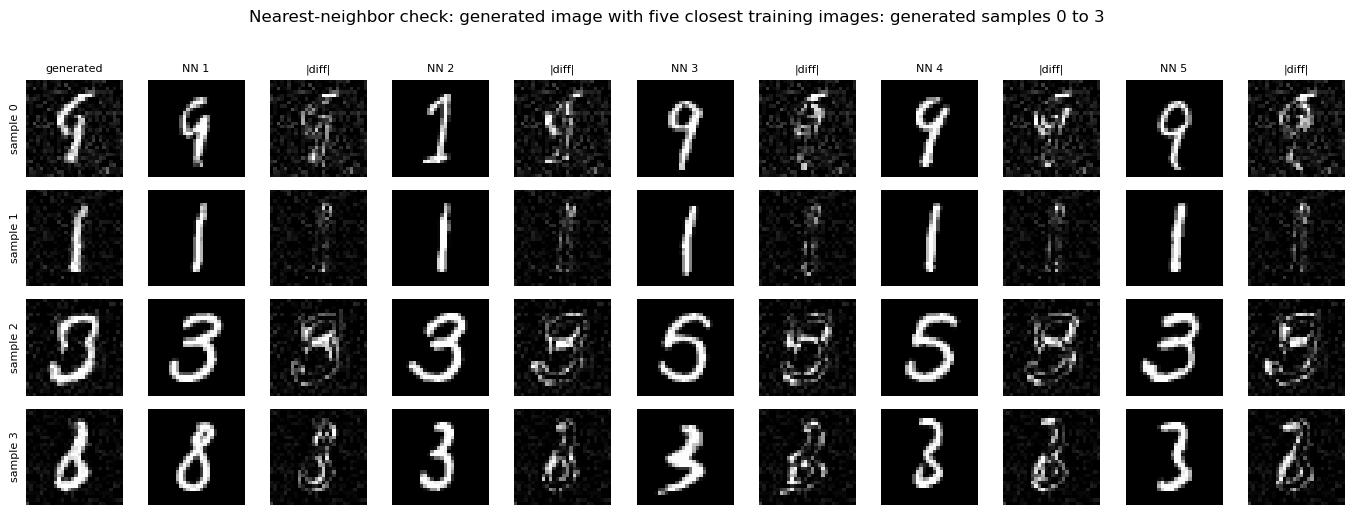

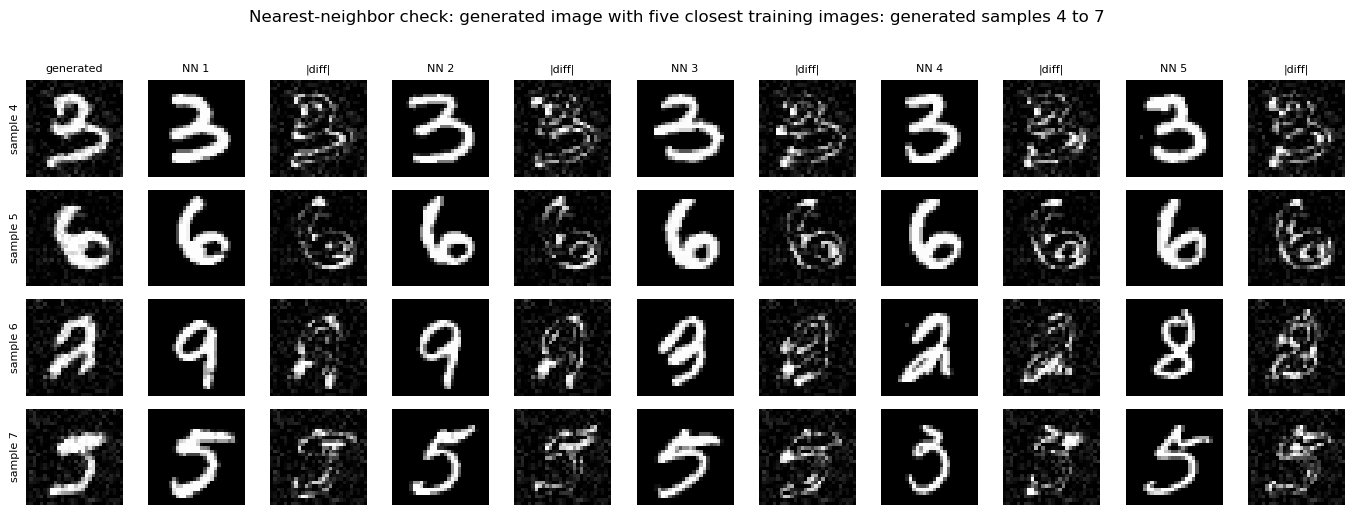

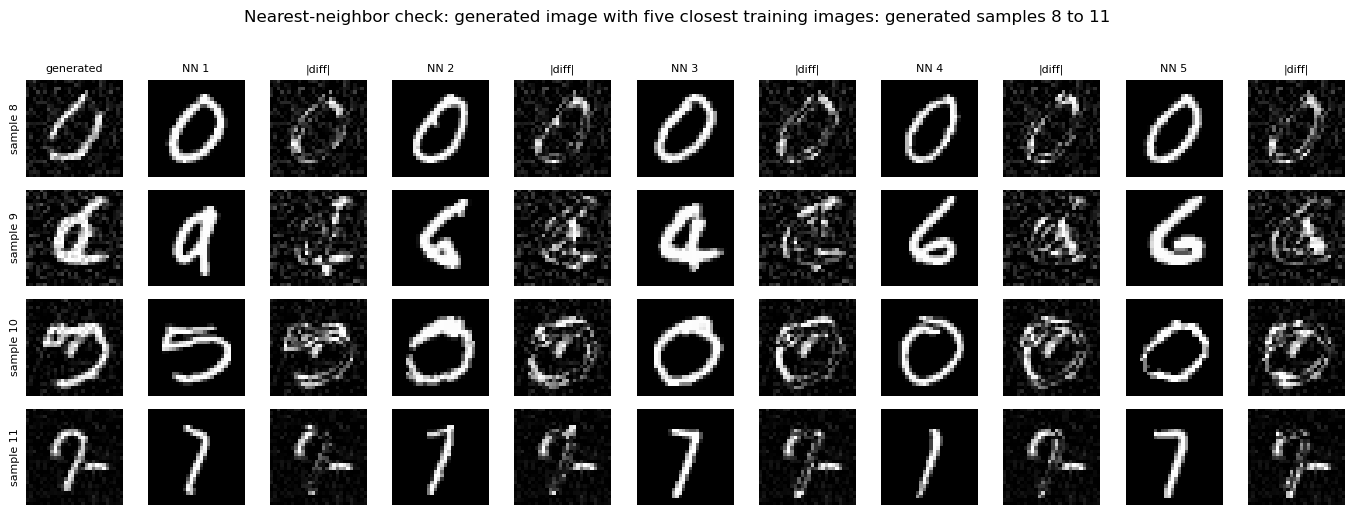

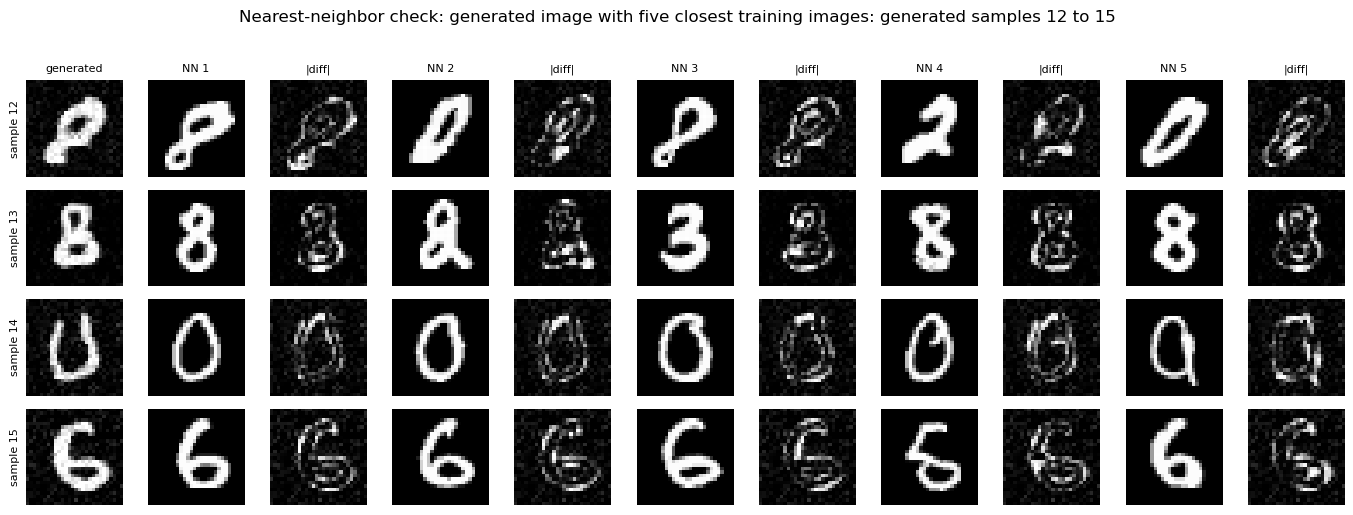

In [14]:
# Generic nearest-neighbor utilities live in knn_helper.py; this cell focuses on the experiment.
# Use the 16 DDPM samples generated in Section 4. If that cell has not been run,
# generate a small DDPM batch now.
num_nn_queries = 16
num_neighbors = 5
if "ddpm_samples" not in globals() or ddpm_samples.shape[0] < num_nn_queries:
    print("ddpm_samples not found; generating 16 DDPM samples for the nearest-neighbor check.")
    if "reverse_grid" not in globals():
        delta = 0.05
        num_sampling_steps = 500 if device.type == "cuda" else 250
        reverse_grid = make_reverse_time_grid(T=T, delta=delta, num_steps=num_sampling_steps, kind="mixed", device=device)
    ddpm_sampler = DDPMSampler(score_model, T=T)
    ddpm_samples = sample_images(ddpm_sampler, reverse_grid, num_samples=num_nn_queries, denoise=True)

if "train_dataset" not in globals():
    train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)

generated_for_nn = ddpm_samples[:num_nn_queries].detach().clamp(-1.0, 1.0)
nearest_images, nearest_labels, nearest_indices, nearest_mse, nearest_rmse, exact_uint8_matches = knn.run_nearest_neighbor_check(
    generated_for_nn,
    train_dataset,
    k=num_neighbors,
    search_device=device,
    max_rows_per_figure=4,
    title_prefix="Nearest-neighbor check: generated image with five closest training images",
)


## Section 6: Small experiments

Try changing

- `num_train_steps`,
- the terminal time `T`,
- the early stopping value `delta`,
- the grid type (`linear`, `geometric`, `mixed`),
- the DDIM noise parameter `eta`.

### Question 3.6 - Discussion

Run the comparison cell below, then answer the following in a markdown cell.

1. What happens when you use too few reverse-time steps?
2. How do DDPM (`eta=1`) and deterministic DDIM (`eta=0`) differ visually?
3. Why do we stop at $q_\delta$ instead of exactly at $q_0$?
4. Why does the final denoising formula help for visualization?


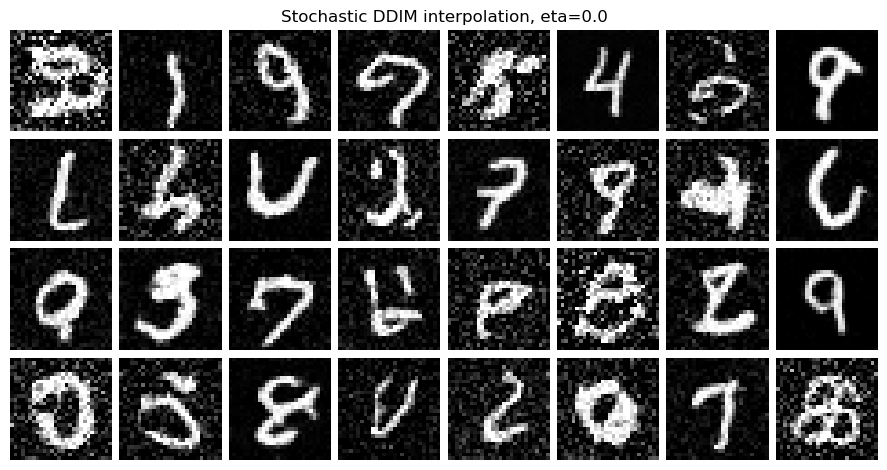

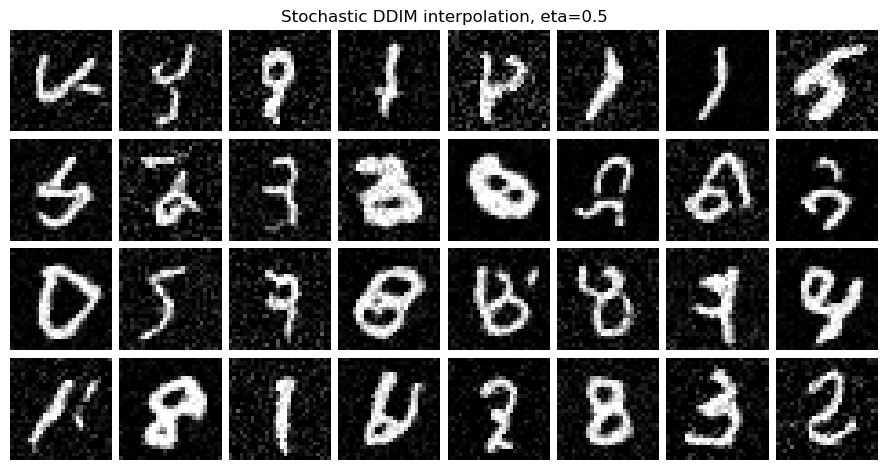

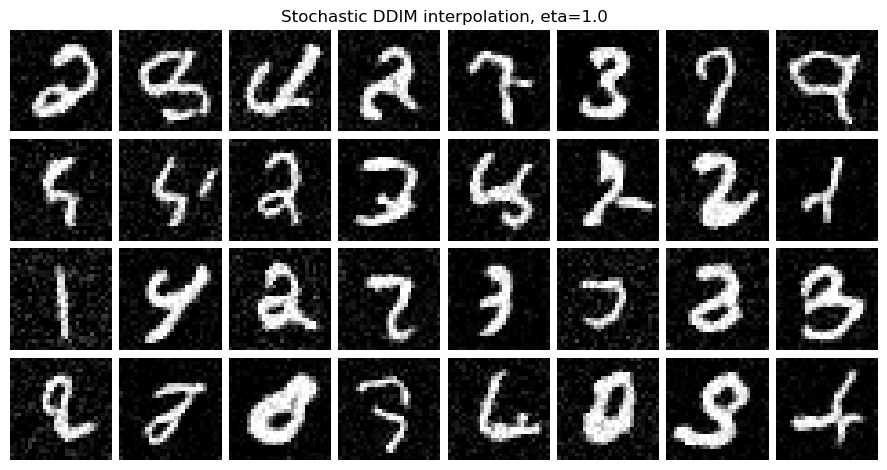

In [15]:
# Compare several eta values in the stochastic DDIM family.
eta_values = [0.0, 0.5, 1.0]
for eta in eta_values:
    sampler = DDIMSampler(score_model, T=T, eta=eta)
    samples = sample_images(sampler, reverse_grid, num_samples=32, denoise=True)
    show_image_grid(samples, nrow=8, title=f"Stochastic DDIM interpolation, eta={eta}")


**Solution discussion.**

1. With too few reverse steps, the discretization error is large. Samples often remain noisy, have broken strokes, or collapse into ambiguous digit-like blobs. The mixed/geometric endpoint grid usually helps because the score changes rapidly near small forward noising time.
2. DDPM uses fresh Gaussian noise at every reverse step, so repeated runs from different terminal noise are more stochastic. Deterministic DDIM follows a probability-flow-type trajectory once the initial terminal noise is fixed, so it often looks smoother but can be less diverse for a weakly trained score model.
3. The score can become singular or very large as $t\downarrow 0$, especially for data distributions concentrated near a low-dimensional image manifold. Stopping at $q_\delta$ keeps the reverse process in a smoothed distribution where the score is better behaved.
4. At the final time $\delta$, the sample is still slightly OU-noised. The formula $e^\delta(x_\delta+\sigma_\delta^2s_\delta(x_\delta))$ is the score-based posterior-mean/Tweedie estimate of the clean image, so it removes some of this last small amount of noise.
